DIMENTIONALITY REDUCTION TECHNIQUES:

1. PCA

2. T-SNE

In [13]:
import pandas as pd                     #for loading and hanling datasets
import numpy as np                      #for numerical computation
#visulization
import matplotlib.pyplot as plt
import seaborn as sns
#preprocessing
from sklearn.model_selection import train_test_split #splitting datasets
from sklearn.preprocessing import  StandardScaler    #scalling features
#knn model
from sklearn.neighbors import KNeighborsClassifier #classification
#Evalution
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#dimentionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [14]:
df=pd.read_csv('/content/WineQT.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [16]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [17]:
X=df[['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']]
y=df['quality']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
scaler=StandardScaler()
X_trained_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

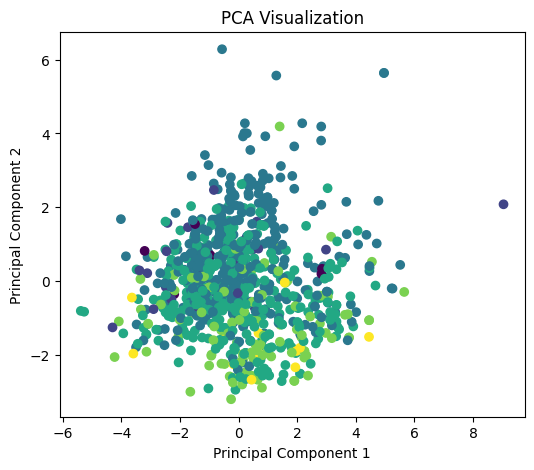

[0.28278769 0.17229535 0.14784708 0.10869558 0.08834021 0.06028357
 0.05020675 0.03741103 0.03083875]


In [35]:
pca=PCA(n_components=0.95)
X_train_pca=pca.fit_transform(X_trained_scaled)
plt.figure(figsize=(6,5))
plt.scatter(X_train_pca[:,0],X_train_pca[:,1],c=y_train)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()
print(pca.explained_variance_ratio_)

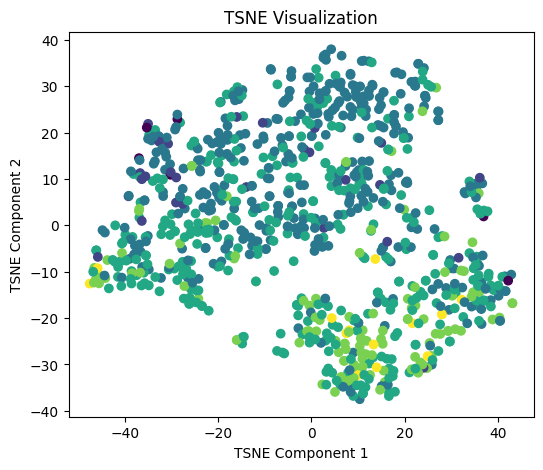

In [42]:
tsne=TSNE(n_components=2,random_state=42)
X_train_tsne=tsne.fit_transform(X_trained_scaled)
plt.figure(figsize=(6,5))
plt.scatter(X_train_tsne[:,0],X_train_tsne[:,1],c=y_train)
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title('TSNE Visualization')
plt.show()

In [36]:
knn =KNeighborsClassifier(n_neighbors=5)

In [37]:
knn.fit(X_trained_scaled, y_train)


KNeighborsClassifier()

In [38]:
y_pred=knn.predict(X_test_scaled)

In [39]:
print("accuracy:",accuracy_score(y_test,y_pred))
print("\nconfusion matrix:",confusion_matrix(y_test,y_pred))
print("classification report:",classification_report(y_test,y_pred))

accuracy: 0.5589519650655022

confusion matrix: [[ 0  4  2  0  0]
 [ 2 66 28  0  0]
 [ 1 34 55  9  0]
 [ 0  5 14  7  0]
 [ 0  0  2  0  0]]
classification report:               precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.61      0.69      0.64        96
           6       0.54      0.56      0.55        99
           7       0.44      0.27      0.33        26
           8       0.00      0.00      0.00         2

    accuracy                           0.56       229
   macro avg       0.32      0.30      0.31       229
weighted avg       0.54      0.56      0.55       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
